# Titanic — Improved Model
Improvements over baseline:
- Richer feature engineering
- XGBoost, LightGBM, GradientBoosting
- Hyperparameter tuning with GridSearchCV
- Voting ensemble of best models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_theme(style='whitegrid')

train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
print('Train:', train.shape, '| Test:', test.shape)

Train: (891, 12) | Test: (418, 11)


## 1. Enhanced Feature Engineering

In [2]:
def engineer_features(df):
    df = df.copy()

    # --- Title ---
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace(
        ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
    df['Title'] = df['Title'].replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})

    # --- Age: fill by median of Title x Pclass ---
    df['Age'] = df.groupby(['Title','Pclass'])['Age'].transform(
        lambda x: x.fillna(x.median()))
    df['Age'] = df['Age'].fillna(df['Age'].median())

    # --- Fare ---
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())

    # --- Embarked ---
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    # --- Cabin ---
    df['HasCabin'] = df['Cabin'].notna().astype(int)
    df['CabinDeck'] = df['Cabin'].str[0].fillna('U')  # U = unknown

    # --- Family ---
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    df['FamilyGroup'] = pd.cut(df['FamilySize'], bins=[0,1,4,20],
                                labels=['Alone','Small','Large'])

    # --- Ticket prefix ---
    df['TicketPrefix'] = df['Ticket'].str.extract(r'^([A-Za-z]+)', expand=False).fillna('NUM')
    df['TicketPrefix'] = df['TicketPrefix'].str.upper().str.replace('[^A-Z]','',regex=True)
    # Keep only common prefixes, lump rest as OTHER
    common = df['TicketPrefix'].value_counts().index[:10]
    df['TicketPrefix'] = df['TicketPrefix'].where(df['TicketPrefix'].isin(common), 'OTHER')

    # --- Fare per person ---
    df['FarePerPerson'] = df['Fare'] / df['FamilySize']

    # --- Interaction: Pclass x Sex ---
    df['Pclass_Sex'] = df['Pclass'].astype(str) + '_' + df['Sex']

    # --- Age groups ---
    df['IsChild'] = (df['Age'] < 12).astype(int)
    df['IsSenior'] = (df['Age'] > 60).astype(int)

    # --- Fare bands ---
    df['FareBand'] = pd.qcut(df['Fare'], 4, labels=False, duplicates='drop')

    # --- Encode categoricals ---
    le = LabelEncoder()
    for col in ['Sex','Embarked','Title','CabinDeck','FamilyGroup','TicketPrefix','Pclass_Sex']:
        df[col] = le.fit_transform(df[col].astype(str))

    return df

train_fe = engineer_features(train)
test_fe  = engineer_features(test)

FEATURES = [
    'Pclass','Sex','Age','SibSp','Parch','Fare','Embarked',
    'Title','HasCabin','CabinDeck','FamilySize','IsAlone','FamilyGroup',
    'TicketPrefix','FarePerPerson','Pclass_Sex','IsChild','IsSenior','FareBand'
]

X = train_fe[FEATURES]
y = train_fe['Survived']
X_test_final = test_fe[FEATURES]

print(f'{len(FEATURES)} features ready')

19 features ready


## 2. Baseline Comparison (5-fold CV)

Logistic Regression        mean=0.8047  std=0.0174
Random Forest              mean=0.8215  std=0.0223
Gradient Boosting          mean=0.8283  std=0.0188
XGBoost                    mean=0.8170  std=0.0232
LightGBM                   mean=0.8193  std=0.0203


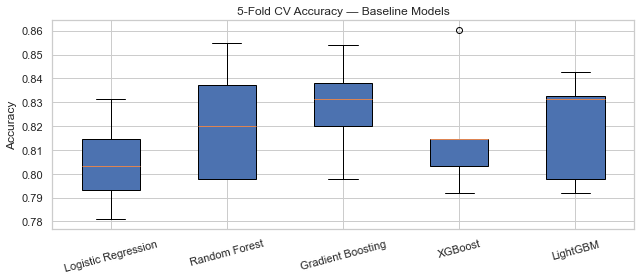

In [3]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_models = {
    'Logistic Regression':    LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':          RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':      GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost':                XGBClassifier(n_estimators=100, random_state=42, verbosity=0),
    'LightGBM':               LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
}

results = {}
for name, model in baseline_models.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
    results[name] = scores
    print(f'{name:25s}  mean={scores.mean():.4f}  std={scores.std():.4f}')

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(results.values(), labels=results.keys(), patch_artist=True)
ax.set_title('5-Fold CV Accuracy — Baseline Models')
ax.set_ylabel('Accuracy')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 3. Hyperparameter Tuning (GridSearchCV)

In [4]:
# Tune Random Forest
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=skf, scoring='accuracy', n_jobs=-1, verbose=0
)
rf_grid.fit(X, y)
print('Best RF params:  ', rf_grid.best_params_)
print('Best RF CV score:', f'{rf_grid.best_score_:.4f}')

Best RF params:   {'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best RF CV score: 0.8350


In [5]:
# Tune XGBoost
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, verbosity=0),
    xgb_params, cv=skf, scoring='accuracy', n_jobs=-1, verbose=0
)
xgb_grid.fit(X, y)
print('Best XGB params:  ', xgb_grid.best_params_)
print('Best XGB CV score:', f'{xgb_grid.best_score_:.4f}')

Best XGB params:   {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Best XGB CV score: 0.8462


In [6]:
# Tune LightGBM
lgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 50],
}
lgb_grid = GridSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    lgb_params, cv=skf, scoring='accuracy', n_jobs=-1, verbose=0
)
lgb_grid.fit(X, y)
print('Best LGB params:  ', lgb_grid.best_params_)
print('Best LGB CV score:', f'{lgb_grid.best_score_:.4f}')

Best LGB params:   {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100, 'num_leaves': 31}
Best LGB CV score: 0.8462


## 4. Voting Ensemble of Best Models

In [7]:
best_rf  = rf_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_
best_lgb = lgb_grid.best_estimator_

ensemble = VotingClassifier(
    estimators=[
        ('rf',  best_rf),
        ('xgb', best_xgb),
        ('lgb', best_lgb),
    ],
    voting='soft'  # uses predicted probabilities
)

ensemble_scores = cross_val_score(ensemble, X, y, cv=skf, scoring='accuracy')
print(f'Ensemble CV accuracy: {ensemble_scores.mean():.4f} ± {ensemble_scores.std():.4f}')

# Compare all tuned models
print('\n--- Summary ---')
print(f'Random Forest:  {rf_grid.best_score_:.4f}')
print(f'XGBoost:        {xgb_grid.best_score_:.4f}')
print(f'LightGBM:       {lgb_grid.best_score_:.4f}')
print(f'Voting Ensemble:{ensemble_scores.mean():.4f}')

Ensemble CV accuracy: 0.8361 ± 0.0167

--- Summary ---
Random Forest:  0.8350
XGBoost:        0.8462
LightGBM:       0.8462
Voting Ensemble:0.8361


## 5. Feature Importance (XGBoost)

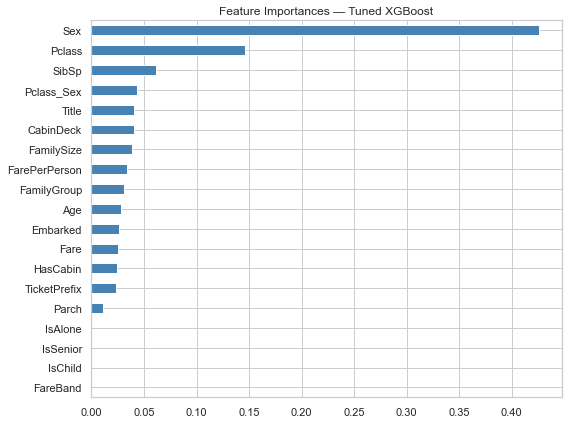

In [8]:
best_xgb.fit(X, y)
importances = pd.Series(best_xgb.feature_importances_, index=FEATURES).sort_values(ascending=True)
importances.plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title('Feature Importances — Tuned XGBoost')
plt.tight_layout()
plt.show()

## 6. Generate Submission

In [10]:
# Use whichever model scored highest
scores = {
    'rf':       rf_grid.best_score_,
    'xgb':      xgb_grid.best_score_,
    'lgb':      lgb_grid.best_score_,
    'ensemble': ensemble_scores.mean(),
}
best_name = max(scores, key=scores.get)
best_model = {'rf': best_rf, 'xgb': best_xgb, 'lgb': best_lgb, 'ensemble': ensemble}[best_name]
print(f'Using: {best_name} (CV={scores[best_name]:.4f})')

best_model.fit(X, y)
predictions = best_model.predict(X_test_final)

submission = pd.DataFrame({'PassengerId': test['PassengerId'], 'Survived': predictions})
submission.to_csv('submission_improved.csv', index=False)
print('submission_improved.csv saved!')
submission.head(10)

Using: xgb (CV=0.8462)
submission_improved.csv saved!


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
5,897,0
6,898,0
7,899,0
8,900,1
9,901,0


In [ ]:
# Ann push test